In [22]:
import pandas as pd

# Load data from yahoo fincance to a dataframe
import yfinance as yf

tickers = [
    "SBK.JO","FSR.JO","ABG.JO","NED.JO",
    "AGL.JO","IMP.JO",
    "SHP.JO","PIK.JO","WHL.JO",
    "MTN.JO","VOD.JO",
    "BVT.JO","REM.JO",
    "SOL.JO","NPN.JO","PRX.JO"
]

df = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]

# Display the first 5 rows and info of the DataFrame
display(df.head())
df.info()

/tmp/ipykernel_9131/1500372.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]
[*********************100%***********************]  16 of 16 completed


Ticker,ABG.JO,AGL.JO,BVT.JO,FSR.JO,IMP.JO,MTN.JO,NED.JO,NPN.JO,PIK.JO,PRX.JO,REM.JO,SBK.JO,SHP.JO,SOL.JO,VOD.JO,WHL.JO
Date,,,,,,,,,,,,,,,,
2020-01-02,15004.889648,39658.980469,20505.820312,6302.160156,14288.040039,8347.368164,21655.154297,46741.820312,6377.471191,49022.402344,13958.857422,16812.164062,12502.412109,30347.042969,11561.832031,4938.207031
2020-01-03,14897.350586,39601.363281,20518.791016,6208.500000,14799.539062,8105.877441,21479.919922,47071.761719,6338.523438,48957.710938,13930.948242,16656.791016,12349.690430,31161.025391,11544.892578,4929.226562
2020-01-06,14474.158203,39232.289062,20261.343750,5983.315918,14577.191406,8022.054688,21061.771484,46867.792969,6148.777344,48861.820312,13686.910156,16273.336914,11976.364258,31795.232422,11368.503906,4777.558594
2020-01-07,14097.766602,39118.050781,20364.123047,6018.188965,14457.543945,8023.052246,21205.138672,47153.746094,6236.660645,49568.355469,13715.537109,16286.285156,12178.000977,31495.607422,11470.151367,4794.520508
2020-01-08,14234.183594,39172.734375,20448.943359,6014.204102,15245.229492,7944.218750,20889.537109,46491.863281,6246.646973,49409.152344,13703.370117,16369.946289,12206.949219,31103.097656,11460.185547,4871.353516


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1250 entries, 2020-01-02 to 2024-12-31
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ABG.JO  1250 non-null   float64
 1   AGL.JO  1250 non-null   float64
 2   BVT.JO  1250 non-null   float64
 3   FSR.JO  1250 non-null   float64
 4   IMP.JO  1250 non-null   float64
 5   MTN.JO  1250 non-null   float64
 6   NED.JO  1250 non-null   float64
 7   NPN.JO  1250 non-null   float64
 8   PIK.JO  1250 non-null   float64
 9   PRX.JO  1250 non-null   float64
 10  REM.JO  1250 non-null   float64
 11  SBK.JO  1250 non-null   float64
 12  SHP.JO  1250 non-null   float64
 13  SOL.JO  1250 non-null   float64
 14  VOD.JO  1250 non-null   float64
 15  WHL.JO  1250 non-null   float64
dtypes: float64(16)
memory usage: 166.0 KB


In [23]:
# Calculate daily returns (already available in the DataFrame)
daily_returns = np.log(df / df.shift(1)).dropna()

# Annualized metrics
annual_returns = daily_returns.mean() * 252
annual_cov_matrix = daily_returns.cov() * 252

# Calculate annualized average returns
annual_returns = daily_returns.mean() * 252  # 252 trading days in a year

# Calculate annualized covariance matrix
annual_cov_matrix = daily_returns.cov() * 252

print("Annualized Average Returns:")
display(annual_returns)

print("\nAnnualized Covariance Matrix:")
display(annual_cov_matrix)

Annualized Average Returns:


,0
Ticker,
ABG.JO,0.047119
AGL.JO,0.063153
BVT.JO,0.050600
FSR.JO,0.037493
IMP.JO,-0.098417
MTN.JO,0.019485
NED.JO,0.052809
NPN.JO,0.116968
PIK.JO,-0.147507



Annualized Covariance Matrix:


Ticker,ABG.JO,AGL.JO,BVT.JO,FSR.JO,IMP.JO,MTN.JO,NED.JO,NPN.JO,PIK.JO,PRX.JO,REM.JO,SBK.JO,SHP.JO,SOL.JO,VOD.JO,WHL.JO
Ticker,,,,,,,,,,,,,,,,
ABG.JO,0.144152,0.045843,0.066467,0.097553,0.056549,0.076331,0.121835,0.013795,0.033417,0.003744,0.069904,0.102221,0.043242,0.102190,0.029511,0.069479
AGL.JO,0.045843,0.177518,0.028354,0.045563,0.138832,0.056238,0.047002,0.042608,0.024522,0.043192,0.035035,0.045009,0.019433,0.131017,0.018850,0.034246
BVT.JO,0.066467,0.028354,0.099422,0.061115,0.048630,0.050685,0.072518,0.008899,0.030523,0.003054,0.051835,0.062379,0.040873,0.061972,0.031611,0.057816
FSR.JO,0.097553,0.045563,0.061115,0.114259,0.054476,0.070505,0.100688,0.016416,0.035434,0.007255,0.065951,0.091917,0.042473,0.082505,0.029935,0.058770
IMP.JO,0.056549,0.138832,0.048630,0.054476,0.379728,0.076604,0.072127,0.055420,0.027220,0.049844,0.049034,0.061950,0.029920,0.173427,0.028157,0.053639
MTN.JO,0.076331,0.056238,0.050685,0.070505,0.076604,0.212324,0.083185,0.022608,0.035941,0.016587,0.060318,0.071401,0.038805,0.133970,0.053824,0.056615
NED.JO,0.121835,0.047002,0.072518,0.100688,0.072127,0.083185,0.156496,0.012668,0.033679,0.001073,0.074606,0.108968,0.044556,0.120060,0.030005,0.074267
NPN.JO,0.013795,0.042608,0.008899,0.016416,0.055420,0.022608,0.012668,0.191446,0.016787,0.168613,0.018579,0.017060,0.009467,0.028518,0.011596,0.023341
PIK.JO,0.033417,0.024522,0.030523,0.035434,0.027220,0.035941,0.033679,0.016787,0.155228,0.012175,0.029392,0.034779,0.050984,0.034970,0.027331,0.045292


In [24]:
# Calculate daily returns (already available in the DataFrame)
daily_returns = df.copy()


print("Daily Average Returns:")
display(daily_returns.mean())

print("\nDaily Covariance Matrix:")
display(daily_returns.cov())

Daily Average Returns:


,0
Ticker,
ABG.JO,15041.708045
AGL.JO,53391.416216
BVT.JO,21418.905091
FSR.JO,6084.652355
IMP.JO,16005.481818
MTN.JO,10743.237016
NED.JO,19272.803749
NPN.JO,59717.359987
PIK.JO,4515.562377



Daily Covariance Matrix:


Ticker,ABG.JO,AGL.JO,BVT.JO,FSR.JO,IMP.JO,MTN.JO,NED.JO,NPN.JO,PIK.JO,PRX.JO,REM.JO,SBK.JO,SHP.JO,SOL.JO,VOD.JO,WHL.JO
Ticker,,,,,,,,,,,,,,,,
ABG.JO,1.102273e+07,2.236925e+07,1.150614e+07,3.243728e+06,-8.803711e+04,8.345293e+06,1.466914e+07,-1.857796e+06,-9.720483e+05,-1.803116e+07,5.948548e+06,9.173640e+06,1.557124e+07,1.597423e+07,-4.477715e+05,3.761366e+06
AGL.JO,2.236925e+07,1.164757e+08,1.267965e+07,5.731513e+06,3.949501e+07,3.087281e+07,2.362122e+07,-2.899569e+07,2.240036e+06,-3.685805e+07,7.909037e+06,8.692985e+06,2.460715e+07,6.416379e+07,6.948504e+06,6.717215e+06
BVT.JO,1.150614e+07,1.267965e+07,1.954166e+07,4.627249e+06,-1.200208e+07,4.838462e+06,2.154355e+07,1.863195e+07,-4.086347e+06,-9.274002e+06,8.031454e+06,1.532874e+07,2.310875e+07,3.990634e+06,-3.522509e+06,4.829962e+06
FSR.JO,3.243728e+06,5.731513e+06,4.627249e+06,1.355759e+06,-1.702114e+06,2.060413e+06,5.952534e+06,2.338069e+06,-7.922910e+05,-4.026819e+06,2.134262e+06,4.012139e+06,6.199362e+06,2.722437e+06,-4.928931e+05,1.199558e+06
IMP.JO,-8.803711e+04,3.949501e+07,-1.200208e+07,-1.702114e+06,3.509257e+07,9.418775e+06,-9.500137e+06,-2.854926e+07,5.791069e+06,-4.809043e+06,-3.766617e+06,-1.084270e+07,-1.343568e+07,2.804301e+07,7.015217e+06,-1.205654e+06
MTN.JO,8.345293e+06,3.087281e+07,4.838462e+06,2.060413e+06,9.418775e+06,1.363983e+07,7.888739e+06,-2.368984e+07,1.001232e+06,-2.672789e+07,4.154832e+06,2.878851e+06,8.593649e+06,2.695268e+07,2.892576e+06,2.522829e+06
NED.JO,1.466914e+07,2.362122e+07,2.154355e+07,5.952534e+06,-9.500137e+06,7.888739e+06,2.817578e+07,1.470433e+07,-3.865563e+06,-1.680090e+07,9.529671e+06,1.865998e+07,2.821578e+07,9.597249e+06,-2.944730e+06,5.393001e+06
NPN.JO,-1.857796e+06,-2.899569e+07,1.863195e+07,2.338069e+06,-2.854926e+07,-2.368984e+07,1.470433e+07,1.453868e+08,-1.021340e+07,1.131948e+08,1.834193e+06,1.723277e+07,1.955372e+07,-6.821984e+07,-1.238731e+07,3.030014e+06
PIK.JO,-9.720483e+05,2.240036e+06,-4.086347e+06,-7.922910e+05,5.791069e+06,1.001232e+06,-3.865563e+06,-1.021340e+07,1.931693e+06,-3.846445e+06,-1.255836e+06,-3.516822e+06,-5.298982e+06,5.234647e+06,1.648261e+06,-7.787374e+05


In [25]:
import numpy as np

num_assets = len(annual_returns)
num_portfolios = 50000  # Number of random portfolios to simulate

# Initialize arrays to store portfolio metrics
all_weights = np.zeros((num_portfolios, num_assets))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

In [26]:
# Simulate random portfolios
for x in range(num_portfolios):
    weights = np.array(np.random.random(num_assets))
    weights = weights / np.sum(weights)

    # Save weights
    all_weights[x, :] = weights

    # Calculate portfolio return
    ret_arr[x] = np.sum((weights * annual_returns)) * 1

    # Calculate portfolio volatility
    vol_arr[x] = np.sqrt(np.dot(weights.T, np.dot(annual_cov_matrix, weights))) * 1

    # Calculate Sharpe Ratio (assuming risk-free rate is 0 for simplicity, common in these examples)
    sharpe_arr[x] = ret_arr[x] / vol_arr[x]

In [27]:
max_sharpe_idx = sharpe_arr.argmax()

max_sharpe_ret = ret_arr[max_sharpe_idx]
max_sharpe_vol = vol_arr[max_sharpe_idx]
max_sharpe_weights = all_weights[max_sharpe_idx]

print("Maximum Sharpe Ratio:", sharpe_arr[max_sharpe_idx])
print("Portfolio Return (Max Sharpe):")
display(max_sharpe_ret)
print("Portfolio Volatility (Max Sharpe):")
display(max_sharpe_vol)
print("Portfolio Weights (Max Sharpe):")
display(pd.Series(max_sharpe_weights, index=df.columns))

Maximum Sharpe Ratio: 0.30626490329928036
Portfolio Return (Max Sharpe):


np.float64(0.0706039411268912)

Portfolio Volatility (Max Sharpe):


np.float64(0.23053226264681534)

Portfolio Weights (Max Sharpe):


,0
Ticker,
ABG.JO,0.079021
AGL.JO,0.038638
BVT.JO,0.024792
FSR.JO,0.072032
IMP.JO,0.047593
MTN.JO,0.013950
NED.JO,0.039111
NPN.JO,0.155559
PIK.JO,0.035299


Explained variance ratio per principal component:


,0
0,0.532775
1,0.254593
2,0.161621
3,0.023135
4,0.008483
5,0.006541
6,0.004073
7,0.003085
8,0.001728
9,0.001658



Principal Components (Loadings):


Ticker,ABG.JO,AGL.JO,BVT.JO,FSR.JO,IMP.JO,MTN.JO,NED.JO,NPN.JO,PIK.JO,PRX.JO,REM.JO,SBK.JO,SHP.JO,SOL.JO,VOD.JO,WHL.JO
PC1,-0.088033,-0.360551,-0.008708,-0.015056,-0.151105,-0.166300,-0.051583,0.567452,-0.034177,0.552125,-0.034069,0.005916,-0.036776,-0.418841,-0.050355,-0.016711
PC2,0.201429,0.513335,0.286975,0.076569,-0.039447,0.111053,0.354039,0.460539,-0.058604,0.068823,0.117884,0.239009,0.394878,0.113581,-0.039263,0.082486
PC3,-0.077606,0.510485,-0.218715,-0.044334,0.485612,0.041401,-0.222192,0.060563,0.064744,0.492830,-0.099164,-0.192918,-0.253094,0.164118,0.082573,-0.032831
PC4,0.121717,-0.429693,0.119367,-0.000900,-0.007790,0.078604,-0.017266,0.224335,0.046384,0.149589,0.109314,0.001760,-0.158972,0.814554,0.007477,0.064256
PC5,0.129827,-0.138966,0.105024,0.039536,0.603145,-0.313352,0.372504,0.220065,0.151282,-0.318970,0.000611,0.130183,-0.371528,-0.146645,-0.029580,-0.009532
PC6,0.039170,-0.300657,-0.028118,0.115154,0.345293,0.314872,0.326379,-0.406909,0.047543,0.415584,0.118338,0.265465,0.293026,-0.106478,0.214933,-0.026569
PC7,-0.291529,0.190875,0.113289,0.076402,-0.389459,-0.267066,0.453751,-0.251325,-0.041381,0.250831,-0.078624,0.234087,-0.433022,0.124984,0.053152,-0.190495
PC8,0.090464,0.043592,0.489721,0.001621,-0.074517,0.578075,-0.066730,-0.006583,-0.033433,0.002996,0.224756,-0.134992,-0.497752,-0.254932,0.082178,0.128460
PC9,0.041301,-0.002294,0.630571,0.010269,0.191909,-0.416770,-0.369555,-0.276964,-0.237916,0.179050,-0.044108,0.136740,0.126384,0.012731,-0.182196,0.134612
PC10,0.762541,0.089504,-0.190840,-0.023564,-0.232502,-0.194543,-0.139945,-0.154859,0.328955,0.155273,0.127200,0.217093,-0.162572,-0.086252,0.030310,0.087496


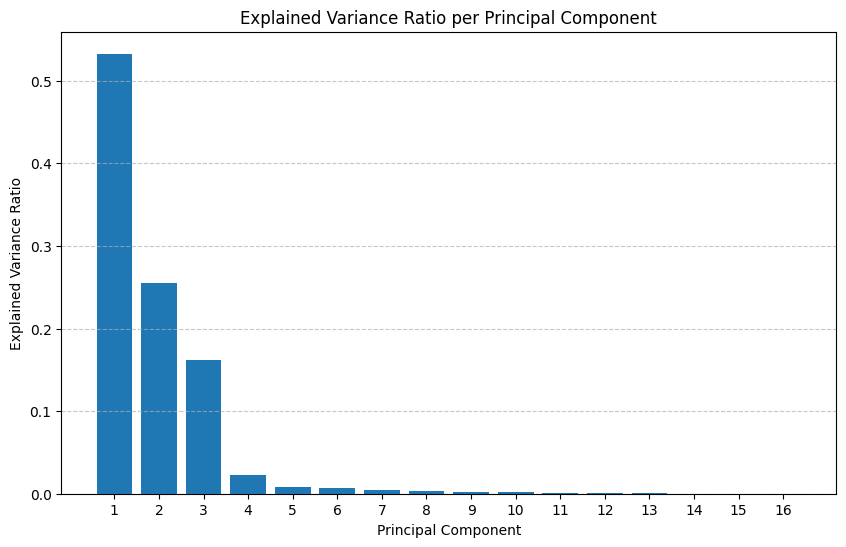

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize PCA with the number of assets
pca = PCA(n_components=num_assets)

# Fit PCA on the daily returns data
pca.fit(daily_returns)

# Display the explained variance ratio for each principal component
print("Explained variance ratio per principal component:")
display(pd.Series(pca.explained_variance_ratio_))

# Display the components (eigenvectors)
print("\nPrincipal Components (Loadings):")
display(pd.DataFrame(pca.components_, columns=df.columns, index=[f'PC{i+1}' for i in range(num_assets)]))

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, num_assets + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per Principal Component')
plt.xticks(range(1, num_assets + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The Principal Component Analysis helps us understand which combination of assets contributes most to the overall risk (volatility) of the portfolio. The first few principal components often explain a large portion of the total variance, indicating the main drivers of risk.

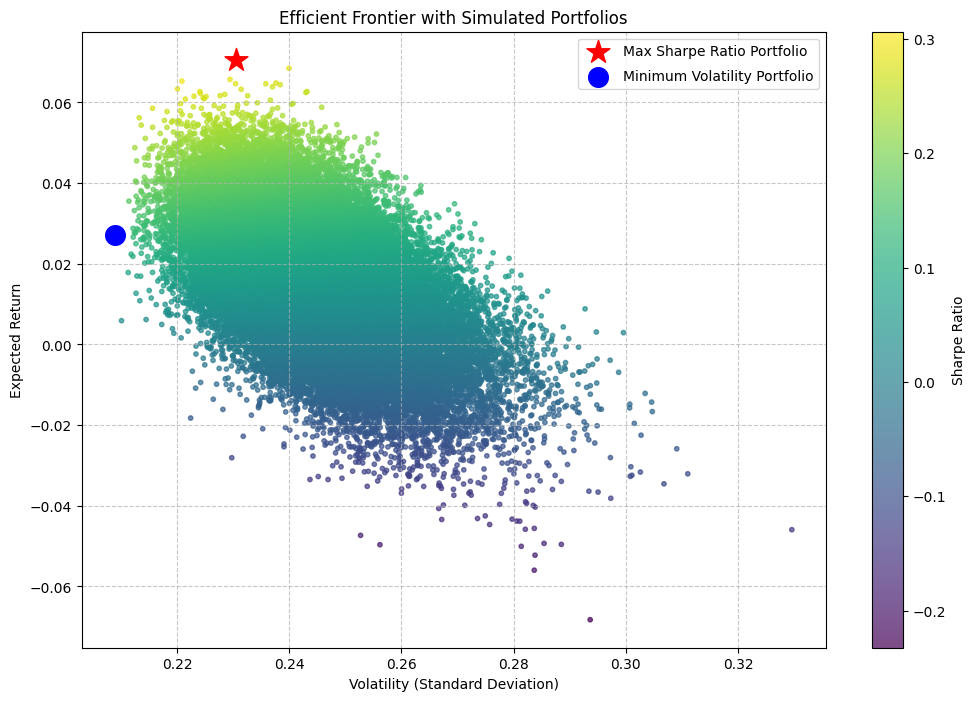

In [29]:
# Create a scatter plot of all simulated portfolios
plt.figure(figsize=(12, 8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Simulated Portfolios')

# Mark the portfolio with the maximum Sharpe Ratio
plt.scatter(max_sharpe_vol, max_sharpe_ret, c='red', marker='*', s=300, label='Max Sharpe Ratio Portfolio')

# Find and mark the minimum volatility portfolio
min_vol_idx = vol_arr.argmin()
min_vol_ret = ret_arr[min_vol_idx]
min_vol_vol = vol_arr[min_vol_idx]
plt.scatter(min_vol_vol, min_vol_ret, c='blue', marker='o', s=200, label='Minimum Volatility Portfolio')

plt.legend(labelspacing=0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [30]:
allocation_for_100 = pd.Series(max_sharpe_weights * 100, index=df.columns)
print("Allocation for R100 based on Max Sharpe Ratio weights:")
display(allocation_for_100)

Allocation for R100 based on Max Sharpe Ratio weights:


,0
Ticker,
ABG.JO,7.902078
AGL.JO,3.863785
BVT.JO,2.479242
FSR.JO,7.203188
IMP.JO,4.759284
MTN.JO,1.394959
NED.JO,3.911053
NPN.JO,15.555922
PIK.JO,3.529855


The plot above visualizes the efficient frontier. Each point represents a simulated portfolio, with its return plotted against its volatility. The color gradient indicates the Sharpe Ratio. The red star marks the portfolio with the highest Sharpe Ratio (our optimal risk-adjusted portfolio), and the blue circle indicates the portfolio with the minimum volatility among all simulated portfolios.

In [31]:
min_sharpe_weights = all_weights[sharpe_arr.argmin()]
allocation_for_100 = pd.Series(min_sharpe_weights * 100, index=df.columns)
print("Allocation for R100 based on Max Sharpe Ratio weights:")
display(allocation_for_100)

Allocation for R100 based on Max Sharpe Ratio weights:


,0
Ticker,
ABG.JO,1.618396
AGL.JO,1.879880
BVT.JO,1.267417
FSR.JO,7.893532
IMP.JO,18.690268
MTN.JO,0.973856
NED.JO,13.016245
NPN.JO,2.508524
PIK.JO,20.791236
